# Ensemble Member Lineage

Every downscaled run is assembled from more than one simulation. A scenario that starts
after the historical period ends needs the intervening years filled in, so the pipeline
splices a **bridge** from other experiments before it detrends. This page shows what each
run is actually made of.

The figures are built from `saidownscale.lineage`, which is the table the pipeline itself resolves
against. `docs/srm-provenance.csv` is a re-export of the [SRM provenance Google
Sheet](https://docs.google.com/spreadsheets/d/1HG8PGrkP_pzM99_LvwyIdcCHmSHFdc85FII0N1RYmDk/edit?gid=1557731209#gid=1557731209)
and records the upstream provenance; re-export and overwrite that file when the sheet
changes. The two can drift, so the last section reconciles them rather than assuming they
agree.

Read each bar left to right as the timeseries the pipeline builds for that run:

- **historical** trains the bias correction and anchors the detrend baseline.
- **SSP245** bridges from the end of historical to the start of the SAI scenario.
- **G6-1.5K** is the SAI scenario, and for the termination run it is also a bridge segment.
- **G6-1.5K-END** is the termination-shock run, which resumes G6-1.5K member 002 in 2085.

Rows are split whenever variables in the same run resolve to different parents. CESM2-WACCM
splits `tasmax`/`tasmin`/`dtr` from the standard variables, because the CMIP6 tasmax/tasmin
bug forced those onto a re-run historical member.


In [1]:
from pathlib import Path

import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import pandas as pd

from saidownscale.lineage import all_lineage_keys, diff_against_provenance, resolve_member_lineage
from saidownscale.validation import resolve_member_time_bounds

In [2]:
# Source of truth: the lineage table the pipeline resolves against, not the CSV.
records = []
for gcm, scenario, member, variable in all_lineage_keys():
    entry = resolve_member_lineage(gcm, scenario, member, variable)
    records.append(
        {
            "gcm": gcm,
            "scenario": scenario,
            "member": member,
            "variable": variable,
            "historical_parent": entry.historical,
            "ssp245_parent": entry.ssp245_bridge,
            "ssp245_esgf_parent": entry.ssp245_esgf_bridge,
            "sai_parent": str(entry.sai_parent) if entry.sai_parent else None,
        }
    )

entries = pd.DataFrame.from_records(records)

# Variables that resolve to identical parents share a row; the rest split.
parent_cols = ["historical_parent", "ssp245_parent", "ssp245_esgf_parent", "sai_parent"]
group_cols = ["gcm", "scenario", "member", *parent_cols]
lineage = (
    entries.groupby(group_cols, dropna=False)["variable"]
    .apply(lambda s: "/".join(sorted(s)))
    .reset_index()
    .rename(columns={"variable": "variables"})
)
lineage

,gcm,scenario,member,historical_parent,ssp245_parent,ssp245_esgf_parent,sai_parent,variables
0,CESM2-WACCM,G6-1.5K,001,001,009,NaN,NaN,dtr/tasmax/tasmin
1,CESM2-WACCM,G6-1.5K,001,r1i1p1f1,001,NaN,NaN,hurs/pr/rsds/tas
2,CESM2-WACCM,G6-1.5K,002,001,007,NaN,NaN,dtr/tasmax/tasmin
3,CESM2-WACCM,G6-1.5K,002,r2i1p1f1,002,NaN,NaN,hurs/pr/rsds/tas
4,CESM2-WACCM,G6-1.5K,003,001,008,NaN,NaN,dtr/tasmax/tasmin
5,CESM2-WACCM,G6-1.5K,003,r3i1p1f1,003,NaN,NaN,hurs/pr/rsds/tas
6,CESM2-WACCM,G6-1.5K-END,002,001,007,NaN,G6-1.5K/002,dtr/tasmax/tasmin
7,CESM2-WACCM,G6-1.5K-END,002,r2i1p1f1,002,NaN,G6-1.5K/002,hurs/pr/rsds/tas
8,CESM2-WACCM,SSP245,001,r1i1p1f1,NaN,NaN,NaN,hurs/pr/rsds/tas
9,CESM2-WACCM,SSP245,002,r2i1p1f1,NaN,NaN,NaN,hurs/pr/rsds/tas


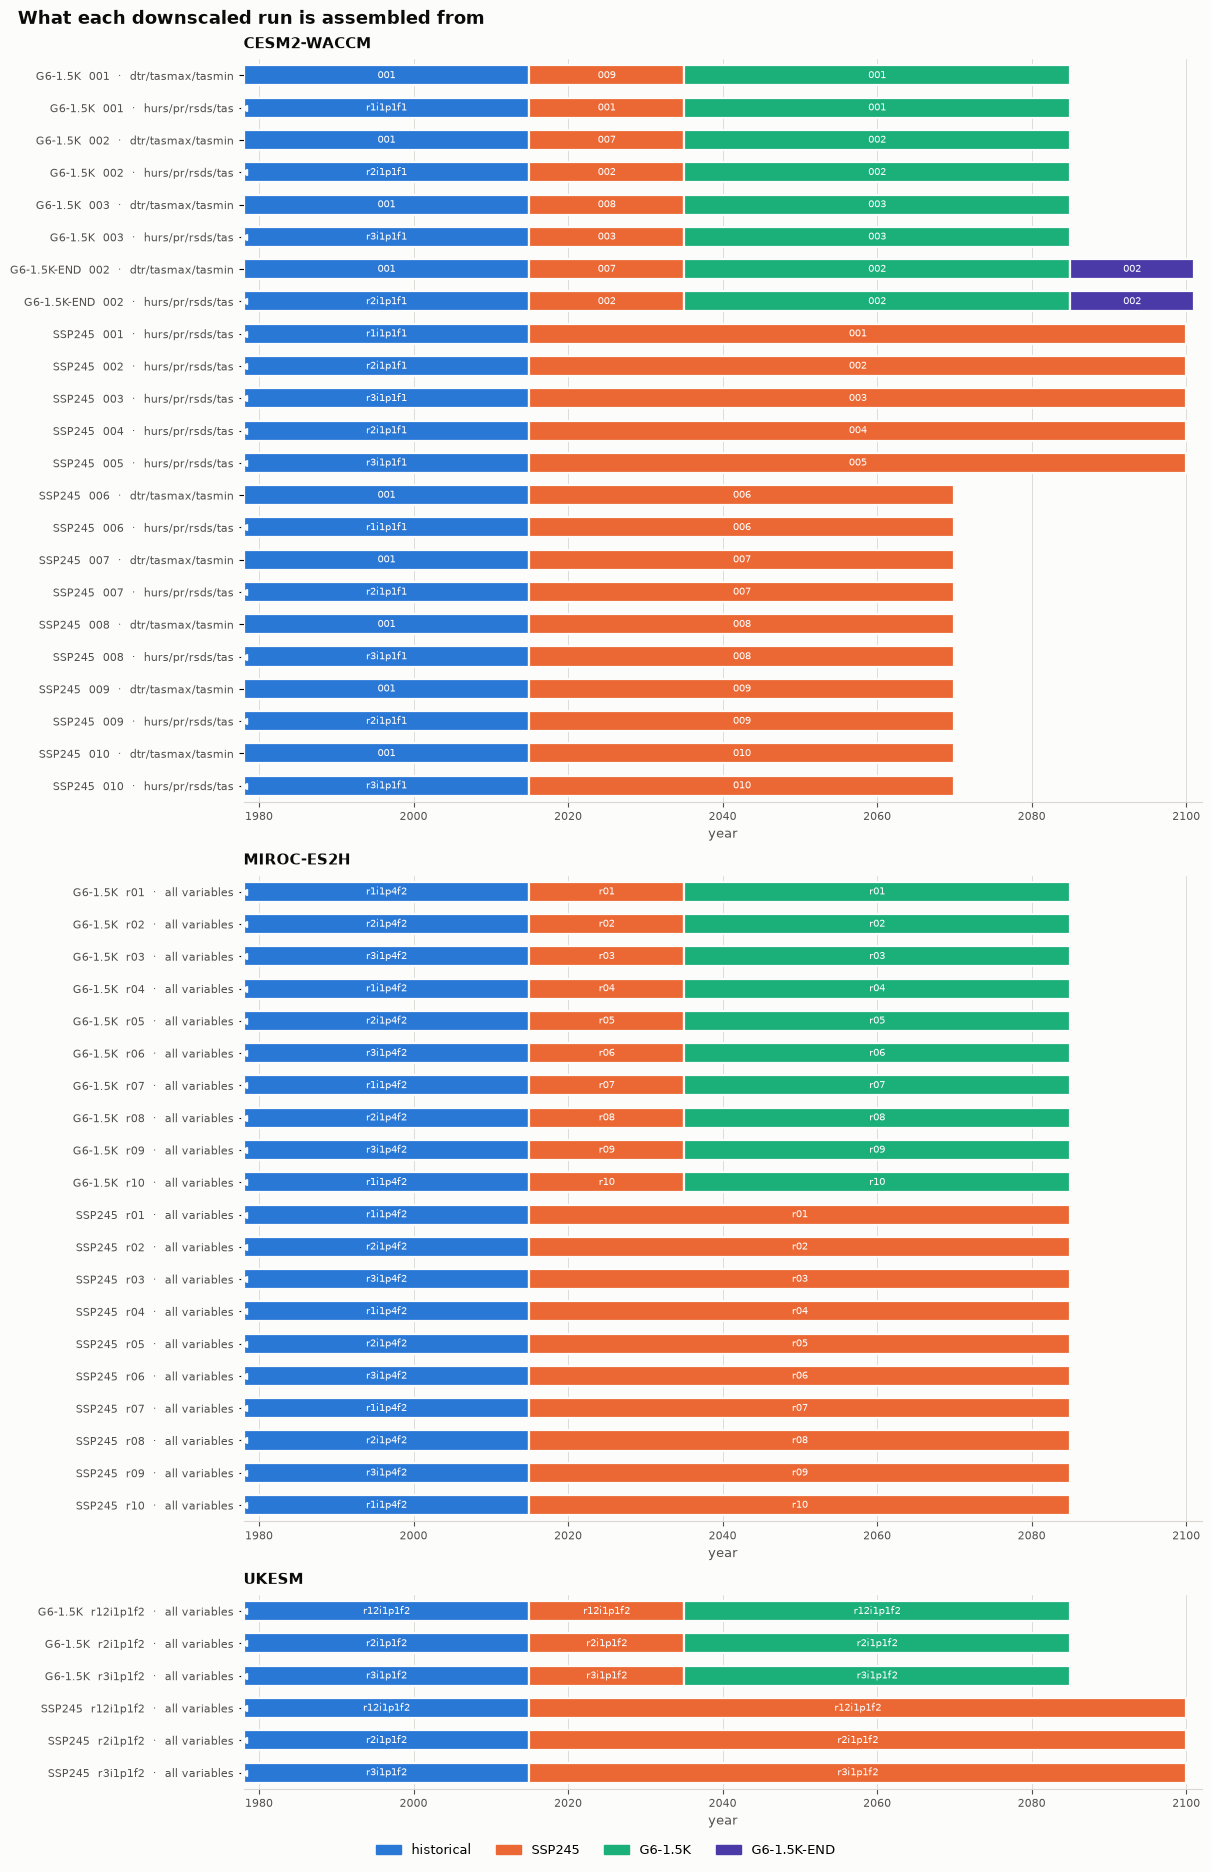

In [3]:
EXPERIMENT_COLOR = {
    "historical": "#2a78d6",
    "SSP245": "#eb6834",
    "G6-1.5K": "#1baf7a",
    "G6-1.5K-END": "#4a3aa7",
}
TEXT_PRIMARY = "#0b0b0b"
TEXT_SECONDARY = "#52514e"
GRID = "#d8d7d2"
SURFACE = "#fcfcfb"

# Historical reaches back to 1850 for some members; the axis starts at the training
# window instead, and clipped bars are capped with a left arrow.
AXIS_START = 1978


def _years(gcm, scenario, member):
    """Return (start_year, end_year) for a run, or None when no bounds are registered."""
    bounds = resolve_member_time_bounds(gcm, scenario, member)
    if bounds is None:
        return None
    return int(bounds[0][:4]), int(bounds[1][:4])


def segments_for(row):
    """Break one lineage row into the ordered segments the pipeline actually reads."""
    gcm, scenario, member = row["gcm"], row["scenario"], row["member"]
    own = _years(gcm, scenario, member)
    if own is None:
        return []
    scenario_start, scenario_end = own

    segs = []
    hist = _years(gcm, "historical", row["historical_parent"])
    if hist is not None:
        segs.append(("historical", hist[0], hist[1], row["historical_parent"], False))

    # The parent SAI run, when present, takes over from its own start year; SSP245 only
    # has to reach that far rather than all the way to the scenario.
    sai_parent = row["sai_parent"]
    parent_start = scenario_start
    if pd.notna(sai_parent) and sai_parent:
        parent_scenario, parent_member = sai_parent.split("/")
        parent = _years(gcm, parent_scenario, parent_member)
        if parent is not None:
            parent_start = parent[0]

    # MIROC carries an ssp245_esgf_parent, but it is not drawn as its own segment: the
    # unified SSP245 store already begins in 2015 with the ESGF years merged in, so the
    # runtime prepend in _load_ssp245_bridge is a no-op and the bridge really is one
    # continuous SSP245 segment.
    ssp245 = row["ssp245_parent"]
    if pd.notna(ssp245) and ssp245 and parent_start > 2015:
        ssp_bounds = _years(gcm, "SSP245", ssp245)
        ssp_start = ssp_bounds[0] if ssp_bounds else 2015
        segs.append(("SSP245", ssp_start, parent_start - 1, ssp245, False))

    if pd.notna(sai_parent) and sai_parent:
        parent_scenario, parent_member = sai_parent.split("/")
        segs.append((parent_scenario, parent_start, scenario_start - 1, parent_member, False))

    segs.append((scenario, scenario_start, scenario_end, member, False))
    return segs


def draw_gcm(gcm, ax):
    rows = lineage[lineage["gcm"] == gcm].sort_values(["scenario", "member", "variables"])
    rows = rows.reset_index(drop=True)
    labels = []

    for y, (_, row) in enumerate(rows.iterrows()):
        for experiment, start, end, label, hatched in segments_for(row):
            left = max(start, AXIS_START)
            width = (end + 1) - left
            if width <= 0:
                continue
            ax.barh(
                y,
                width,
                left=left,
                height=0.62,
                color=EXPERIMENT_COLOR.get(experiment, "#999999"),
                edgecolor=SURFACE,
                linewidth=1.6,  # 2px surface gap between adjacent segments
                hatch="///" if hatched else None,
                zorder=3,
            )
            if width >= 11:
                ax.text(
                    left + width / 2,
                    y,
                    label,
                    ha="center",
                    va="center",
                    fontsize=7.5,
                    color="#ffffff",
                    zorder=4,
                )
            if start < AXIS_START:
                ax.plot(
                    AXIS_START, y, marker="<", color=SURFACE, markersize=5, zorder=5, clip_on=False
                )
        variables = row["variables"]
        if len(variables.split("/")) == 7:
            variables = "all variables"
        labels.append(f"{row['scenario']}  {row['member']}  ·  {variables}")

    ax.set_yticks(range(len(rows)))
    ax.set_yticklabels(labels, fontsize=8, color=TEXT_SECONDARY)
    ax.invert_yaxis()
    ax.set_xlim(AXIS_START, 2102)
    ax.set_ylim(len(rows) - 0.5, -0.5)
    ax.set_xlabel("year", fontsize=9, color=TEXT_SECONDARY)
    ax.set_title(gcm, fontsize=11, fontweight="bold", color=TEXT_PRIMARY, loc="left", pad=8)
    ax.xaxis.grid(True, color=GRID, linewidth=0.6, zorder=0)
    ax.set_axisbelow(True)
    ax.tick_params(axis="x", labelsize=8, colors=TEXT_SECONDARY)
    for side in ("top", "right", "left"):
        ax.spines[side].set_visible(False)
    ax.spines["bottom"].set_color(GRID)


def legend_handles():
    return [mpatches.Patch(color=color, label=name) for name, color in EXPERIMENT_COLOR.items()]


gcms = sorted(lineage["gcm"].unique())
heights = [max(1.6, 0.34 * (lineage["gcm"] == g).sum()) for g in gcms]

fig, axes = plt.subplots(
    len(gcms), 1, figsize=(12, sum(heights) + 1.6), height_ratios=heights, constrained_layout=True
)
fig.patch.set_facecolor(SURFACE)
for ax, gcm in zip(axes, gcms):
    ax.set_facecolor(SURFACE)
    draw_gcm(gcm, ax)

fig.suptitle(
    "What each downscaled run is assembled from",
    fontsize=13,
    fontweight="bold",
    color=TEXT_PRIMARY,
    x=0.01,
    ha="left",
)
fig.legend(
    handles=legend_handles(),
    loc="lower center",
    ncol=4,
    fontsize=9,
    frameon=False,
    bbox_to_anchor=(0.5, -0.02),
)
plt.show()

## Reconciliation against the provenance sheet

The figures above come from `saidownscale.lineage`; the table below is the difference between that
table and `docs/srm-provenance.csv`. Anything listed here is a place where the code and the
upstream sheet disagree, which is worth resolving in one direction or the other.

Two classes of difference are expected rather than errors. `dtr` is derived from
`tasmax - tasmin` rather than stored, so it has no provenance row, and the sheet carries
`historical` rows that the lineage table has no counterpart for because it registers
scenarios only.


In [4]:
drift = diff_against_provenance(Path("../srm-provenance.csv"))

rows = []
for key in drift["only_in_code"]:
    gcm, scenario, member, variable = key
    rows.append(
        {
            "where": "code only",
            "gcm": gcm,
            "scenario": scenario,
            "member": member,
            "variable": variable,
            "note": "derived variable, no sheet row" if variable == "dtr" else "",
        }
    )
for key in drift["only_in_sheet"]:
    gcm, scenario, member, variable = key
    rows.append(
        {
            "where": "sheet only",
            "gcm": gcm,
            "scenario": scenario,
            "member": member,
            "variable": variable,
            "note": "",
        }
    )

drift_table = pd.DataFrame(rows)
unexpected = drift_table[drift_table["note"] == ""]
print(f"{len(drift_table)} key differences, {len(unexpected)} of them unexpected")
print(f"{len(drift['parent_mismatch'])} parent disagreements:")
for line in drift["parent_mismatch"]:
    print("   ", line)

unexpected.reset_index(drop=True)

58 key differences, 46 of them unexpected
7 parent disagreements:
    CESM2-WACCM/SSP245/006/tasmax: historical is '001' in code, 'r1i1p1f1' in the sheet
    UKESM/SSP245/r12i1p1f2/dtr: historical is 'r12i1p1f2' in code, 'r3i1p1f2' in the sheet
    UKESM/SSP245/r12i1p1f2/pr: historical is 'r12i1p1f2' in code, 'r3i1p1f2' in the sheet
    UKESM/SSP245/r2i1p1f2/dtr: historical is 'r2i1p1f2' in code, 'r12i1p1f2' in the sheet
    UKESM/SSP245/r2i1p1f2/pr: historical is 'r2i1p1f2' in code, 'r12i1p1f2' in the sheet
    UKESM/SSP245/r3i1p1f2/dtr: historical is 'r3i1p1f2' in code, 'r2i1p1f2' in the sheet
    UKESM/SSP245/r3i1p1f2/pr: historical is 'r3i1p1f2' in code, 'r2i1p1f2' in the sheet


,where,gcm,scenario,member,variable,note
0,code only,CESM2-WACCM,SSP245,006,tasmin,
1,code only,UKESM,G6-1.5K,r12i1p1f2,pr,
2,code only,UKESM,G6-1.5K,r12i1p1f2,tas,
3,code only,UKESM,G6-1.5K,r12i1p1f2,tasmax,
4,code only,UKESM,G6-1.5K,r12i1p1f2,tasmin,
5,code only,UKESM,G6-1.5K,r2i1p1f2,pr,
6,code only,UKESM,G6-1.5K,r2i1p1f2,tas,
7,code only,UKESM,G6-1.5K,r2i1p1f2,tasmax,
8,code only,UKESM,G6-1.5K,r2i1p1f2,tasmin,
9,code only,UKESM,G6-1.5K,r3i1p1f2,pr,
